In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))

GPU available: True
GPU name: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/archive.zip" "DocTamper Training/images/*" -d "/content/real"

Streaming output truncated to the last 5000 lines.
  inflating: /content/real/DocTamper Training/images/95000.jpg  
  inflating: /content/real/DocTamper Training/images/95001.jpg  
  inflating: /content/real/DocTamper Training/images/95002.jpg  
  inflating: /content/real/DocTamper Training/images/95003.jpg  
  inflating: /content/real/DocTamper Training/images/95004.jpg  
  inflating: /content/real/DocTamper Training/images/95005.jpg  
  inflating: /content/real/DocTamper Training/images/95006.jpg  
  inflating: /content/real/DocTamper Training/images/95007.jpg  
  inflating: /content/real/DocTamper Training/images/95008.jpg  
  inflating: /content/real/DocTamper Training/images/95009.jpg  
  inflating: /content/real/DocTamper Training/images/95010.jpg  
  inflating: /content/real/DocTamper Training/images/95011.jpg  
  inflating: /content/real/DocTamper Training/images/95012.jpg  
  inflating: /content/real/DocTamper Training/images/95013.jpg  
  inflating: /content/real/DocTamper Tr

In [ ]:
!unzip "/content/drive/MyDrive/archive.zip" "DocTamper Training/masks/*" -d "/content/fake"

Streaming output truncated to the last 5000 lines.
  inflating: /content/fake/DocTamper Training/masks/95000.png  
  inflating: /content/fake/DocTamper Training/masks/95001.png  
  inflating: /content/fake/DocTamper Training/masks/95002.png  
  inflating: /content/fake/DocTamper Training/masks/95003.png  
  inflating: /content/fake/DocTamper Training/masks/95004.png  
  inflating: /content/fake/DocTamper Training/masks/95005.png  
  inflating: /content/fake/DocTamper Training/masks/95006.png  
  inflating: /content/fake/DocTamper Training/masks/95007.png  
  inflating: /content/fake/DocTamper Training/masks/95008.png  
  inflating: /content/fake/DocTamper Training/masks/95009.png  
  inflating: /content/fake/DocTamper Training/masks/95010.png  
  inflating: /content/fake/DocTamper Training/masks/95011.png  
  inflating: /content/fake/DocTamper Training/masks/95012.png  
  inflating: /content/fake/DocTamper Training/masks/95013.png  
  inflating: /content/fake/DocTamper Training/masks/9

In [ ]:
import os
import shutil

os.makedirs("/content/dataset", exist_ok=True)

shutil.move("/content/real", "/content/dataset/real")
shutil.move("/content/fake", "/content/dataset/fake")

'/content/dataset/fake'

In [ ]:
import os

os.makedirs("/content/dataset_reduced/real", exist_ok=True)
os.makedirs("/content/dataset_reduced/fake", exist_ok=True)

In [ ]:
import random
import shutil
import os

real_path = "/content/dataset/real/DocTamper Training/images"
fake_path = "/content/dataset/fake/DocTamper Training/masks"

real_files = os.listdir(real_path)
fake_files = os.listdir(fake_path)

real_sample = random.sample(real_files, 8000)
fake_sample = random.sample(fake_files, 8000)

for f in real_sample:
    shutil.copy(os.path.join(real_path, f), "/content/dataset_reduced/real")

for f in fake_sample:
    shutil.copy(os.path.join(fake_path, f), "/content/dataset_reduced/fake")

print("Reduced dataset created")

Reduced dataset created


In [ ]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(15),
    transforms.GaussianBlur(3),
    transforms.ToTensor()
])
test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])
dataset = ImageFolder("/content/dataset_reduced")

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_dataset.dataset.transform = train_transform
test_dataset.dataset.transform = test_transform

In [ ]:
len(dataset)

16000

###CNN

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    num_workers=2,
    pin_memory=True
)

In [ ]:
import torch
import torch.nn as nn
torch.backends.cudnn.benchmark = True
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,2)
        )

    def forward(self,x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0003,
    weight_decay=1e-4
)

In [ ]:
from tqdm import tqdm

epochs = 12

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss:{running_loss/len(train_loader):.6f}")

100%|██████████| 100/100 [00:43<00:00,  2.30it/s]


Epoch 1/12, Loss:0.020898


100%|██████████| 100/100 [00:41<00:00,  2.44it/s]


Epoch 2/12, Loss:0.000044


100%|██████████| 100/100 [00:38<00:00,  2.60it/s]


...

Epoch 10/12, Loss:0.000575


100%|██████████| 100/100 [00:59<00:00,  1.68it/s]


Epoch 11/12, Loss:0.000075


100%|██████████| 100/100 [00:38<00:00,  2.57it/s]

Epoch 12/12, Loss:0.000316


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.97%


In [ ]:
torch.save(model.state_dict(), "model_name.pth")

In [ ]:
import os
os.makedirs("/content/drive/MyDrive/models", exist_ok=True)

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/models/cnn_model.pth")

In [ ]:
results = {}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)

            # For GAN (binary classification with sigmoid output)
            if isinstance(model, LightDiscriminator):
                preds = (outputs > 0.5).int().squeeze()
            # For other models (multi-class with softmax/logits output)
            else:
                _, preds = torch.max(outputs,1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    return acc, prec, rec, f1

###RESNET50

In [ ]:
import torchvision.models as models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
res_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
res_model.fc = nn.Linear(res_model.fc.in_features, 2)
res_model = res_model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(res_model.parameters(), lr=0.0003)

In [ ]:
epochs = 10

for epoch in range(epochs):
    res_model.train()
    running_loss = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = res_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.6f}")

100%|██████████| 100/100 [00:56<00:00,  1.77it/s]


Epoch 1, Loss: 0.020888


100%|██████████| 100/100 [01:14<00:00,  1.35it/s]


Epoch 2, Loss: 0.000294


100%|██████████| 100/100 [01:07<00:00,  1.49it/s]


...

Epoch 8, Loss: 0.000005


100%|██████████| 100/100 [00:55<00:00,  1.80it/s]


Epoch 9, Loss: 0.000003


100%|██████████| 100/100 [00:56<00:00,  1.76it/s]

Epoch 10, Loss: 0.000844


In [ ]:
res_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = res_model(images)
        _, preds = torch.max(outputs,1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("ResNet50 Accuracy:", 100 * correct / total)

ResNet50 Accuracy: 99.96875


In [ ]:
torch.save(res_model.state_dict(), "resnet50_model.pth")

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/models/res_model.pth")

###EFFICIENTNET

In [ ]:
!pip install efficientnet_pytorch

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=a0741db21203c3ad05e8e1b4c78de2f43f5fc52a4507289af7636df54564e0b1
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet_pytorch


In [ ]:
from efficientnet_pytorch import EfficientNet

e_model = EfficientNet.from_pretrained('efficientnet-b0')
e_model._fc = nn.Linear(e_model._fc.in_features, 2)
e_model = e_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(e_model.parameters(), lr=0.0003)

epochs = 10

for epoch in range(epochs):
    e_model.train()
    running_loss = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = e_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.6f}")

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 95.1MB/s]


Loaded pretrained weights for efficientnet-b0


100%|██████████| 100/100 [00:50<00:00,  1.97it/s]


Epoch 1, Loss: 0.032558


...

Epoch 8, Loss: 0.000041


100%|██████████| 100/100 [00:48<00:00,  2.08it/s]


Epoch 9, Loss: 0.000030


100%|██████████| 100/100 [00:48<00:00,  2.04it/s]

Epoch 10, Loss: 0.000022


In [ ]:
e_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = e_model(images)
        _, preds = torch.max(outputs,1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("EfficientNet Accuracy:", 100 * correct / total)

EfficientNet Accuracy: 100.0


In [ ]:
torch.save(e_model.state_dict(), "efficientnet_model.pth")

In [ ]:
torch.save(e_model.state_dict(), "/content/drive/MyDrive/models/efficientnet_model.pth")

###VISION TRANSFORMER

In [ ]:
!pip install timm

In [ ]:
vit_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor()
])

In [ ]:
import torch

# Move models to CPU to free up GPU memory
if 'model' in locals() and model is not None: # CNN model
    model.to('cpu')
    del model
    print("CNN model moved to CPU and deleted.")

if 'res_model' in locals() and res_model is not None: # ResNet50 model
    res_model.to('cpu')
    del res_model
    print("ResNet50 model moved to CPU and deleted.")

if 'e_model' in locals() and e_model is not None: # EfficientNet model
    e_model.to('cpu')
    del e_model
    print("EfficientNet model moved to CPU and deleted.")

# Clear CUDA cache
torch.cuda.empty_cache()
print("CUDA cache cleared.")

CNN model moved to CPU and deleted.
ResNet50 model moved to CPU and deleted.
EfficientNet model moved to CPU and deleted.
CUDA cache cleared.


In [ ]:
train_dataset.dataset.transform = vit_transform
test_dataset.dataset.transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    num_workers=2,
    pin_memory=True
)

In [ ]:
import timm
import torch
torch.cuda.empty_cache()
vit_model = timm.create_model(
    'vit_tiny_patch16_224',
    pretrained=True,
    num_classes=2
)

vit_model = vit_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vit_model.parameters(), lr=0.0003)

epochs = 10

for epoch in range(epochs):

    vit_model.train()
    running_loss = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vit_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.6f}")

100%|██████████| 1600/1600 [01:43<00:00, 15.47it/s]


Epoch 1, Loss: 0.007489


100%|██████████| 1600/1600 [01:37<00:00, 16.34it/s]


Epoch 2, Loss: 0.022344


100%|██████████| 1600/1600 [01:34<00:00, 16.98it/s]


...

Epoch 8, Loss: 0.002720


100%|██████████| 1600/1600 [01:25<00:00, 18.68it/s]


Epoch 9, Loss: 0.001630


100%|██████████| 1600/1600 [01:24<00:00, 18.89it/s]

Epoch 10, Loss: 0.000631


In [ ]:
vit_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = vit_model(images)
        _, preds = torch.max(outputs,1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("ViT Accuracy:", 100 * correct / total)

ViT Accuracy: 99.96875


In [ ]:
torch.save(vit_model.state_dict(), "vit_model.pth")

In [ ]:
torch.save(vit_model.state_dict(), "/content/drive/MyDrive/models/vit_model.pth")

In [ ]:
import torch

if 'vit_model' in locals():
    del vit_model
    print("ViT model deleted")

torch.cuda.empty_cache()

print("GPU memory cleared ")

ViT model deleted
GPU memory cleared 


###GAN

In [ ]:
import torch.nn as nn

class LightDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3,32,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128*16*16,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
import torch.optim as optim
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LightDiscriminator().to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0003
)

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.6f}")

100%|██████████| 194/194 [01:20<00:00,  2.41it/s]


Epoch 1, Loss: 0.006860


100%|██████████| 194/194 [01:18<00:00,  2.48it/s]


Epoch 2, Loss: 0.001808


100%|██████████| 194/194 [01:18<00:00,  2.46it/s]


...

Epoch 8, Loss: 0.001223


100%|██████████| 194/194 [01:17<00:00,  2.51it/s]


Epoch 9, Loss: 0.001761


100%|██████████| 194/194 [01:16<00:00,  2.52it/s]

Epoch 10, Loss: 0.006128


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = (outputs > 0.5).int().squeeze()

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("GAN Accuracy:", 100 * correct / total)

GAN Accuracy: 99.95157384987894


In [ ]:
torch.save(model.state_dict(), "gan_model.pth")

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/models/gan_model.pth")

###HYBRID MODEL: EFFICIENTNET + RESNET50

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
!pip install efficientnet_pytorch
from efficientnet_pytorch import EfficientNet
from tqdm import tqdm

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=7e97e343b5fb5993f8c7474c71708a27e03954b804c1562b9bf21626d386ef39
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet_pytorch


In [ ]:
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()

        # ResNet
        self.resnet = models.resnet50(pretrained=True)
        self.resnet.fc = nn.Identity()

        # EfficientNet
        self.efficientnet = EfficientNet.from_pretrained('efficientnet-b0')
        self.efficientnet._fc = nn.Identity()

        # Freeze both
        for param in self.resnet.parameters():
            param.requires_grad = False

        for param in self.efficientnet.parameters():
            param.requires_grad = False

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 1280, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        f1 = self.resnet(x)
        f2 = self.efficientnet(x)

        combined = torch.cat((f1, f2), dim=1)
        out = self.classifier(combined)

        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hybrid_model = HybridModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(hybrid_model.classifier.parameters(), lr=0.0003)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 80.2MB/s]


Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 176MB/s]


Loaded pretrained weights for efficientnet-b0


In [ ]:
epochs = 5

for epoch in range(epochs):
    hybrid_model.train()
    running_loss = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = hybrid_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.6f}")

100%|██████████| 100/100 [01:00<00:00,  1.65it/s]


Epoch 1, Loss: 0.026655


100%|██████████| 100/100 [00:48<00:00,  2.06it/s]


Epoch 2, Loss: 0.000779


100%|██████████| 100/100 [00:49<00:00,  2.02it/s]


Epoch 3, Loss: 0.000615


100%|██████████| 100/100 [00:47<00:00,  2.12it/s]


Epoch 4, Loss: 0.000193


100%|██████████| 100/100 [00:47<00:00,  2.09it/s]

Epoch 5, Loss: 0.000145


In [ ]:
torch.save(hybrid_model.state_dict(), "/content/drive/MyDrive/models/hybrid_model.pth")

In [ ]:
hybrid_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = hybrid_model(images)

        # Correct prediction method
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

accuracy = 100 * correct / total
print(f"Hybrid Model Accuracy: {accuracy:.2f}%")

Hybrid Model Accuracy: 100.00%


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

!pip install efficientnet_pytorch -q
from efficientnet_pytorch import EfficientNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

  Preparing metadata (setup.py) ... done
Device: cuda


In [ ]:
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = ImageFolder("/content/dataset_reduced")
print("Class mapping:", dataset.class_to_idx)

# Same seed as original split so test set is identical
torch.manual_seed(42)
train_size = int(0.8 * len(dataset))
test_size  = len(dataset) - train_size
_, test_dataset = random_split(dataset, [train_size, test_size])

test_dataset.dataset.transform = test_transform

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Test samples: {len(test_dataset)}")

Class mapping: {'fake': 0, 'real': 1}
Test samples: 3200


In [ ]:
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.resnet = models.resnet50(weights=None)
        self.resnet.fc = nn.Identity()

        self.efficientnet = EfficientNet.from_pretrained('efficientnet-b0')
        self.efficientnet._fc = nn.Identity()

        for param in self.resnet.parameters():
            param.requires_grad = False
        for param in self.efficientnet.parameters():
            param.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Linear(2048 + 1280, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        f1 = self.resnet(x)
        f2 = self.efficientnet(x)
        return self.classifier(torch.cat((f1, f2), dim=1))


hybrid_model = HybridModel()
hybrid_model.load_state_dict(
    torch.load("/content/drive/MyDrive/models/hybrid_model.pth",
               map_location=device)
)
hybrid_model = hybrid_model.to(device)
hybrid_model.eval()
print("Hybrid model loaded from Drive ")

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 44.6MB/s]


Loaded pretrained weights for efficientnet-b0
Hybrid model loaded from Drive 


In [ ]:
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images = images.to(device)

        outputs = hybrid_model(images)
        probs   = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

Evaluating: 100%|██████████| 100/100 [00:15<00:00,  6.30it/s]


In [ ]:
acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec  = recall_score(all_labels,   all_preds, zero_division=0)
f1   = f1_score(all_labels,       all_preds, zero_division=0)

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc     = auc(fpr, tpr)

print("=" * 44)
print("  Hybrid Model (ResNet50 + EfficientNet-B0)")
print("=" * 44)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")
print(f"  ROC AUC   : {roc_auc:.4f}")
print("=" * 44)

  Hybrid Model (ResNet50 + EfficientNet-B0)
  Accuracy  : 100.00%
  Precision : 100.00%
  Recall    : 100.00%
  F1 Score  : 100.00%
  ROC AUC   : 1.0000


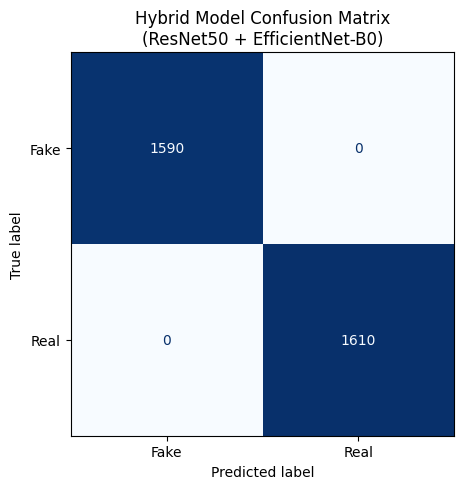

In [ ]:
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Fake", "Real"])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Hybrid Model Confusion Matrix\n(ResNet50 + EfficientNet-B0)", fontsize=12)
plt.tight_layout()
plt.show()

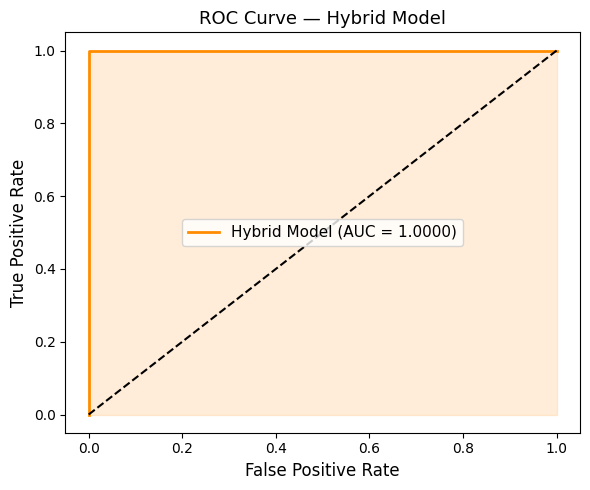

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Hybrid Model (AUC = {roc_auc:.4f})')
plt.fill_between(fpr, tpr, alpha=0.15, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate",  fontsize=12)
plt.title("ROC Curve — Hybrid Model", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

###VARIATIONAL GAN (VAE-GAN)

In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch

# Confirm GPU is healthy before doing anything else
print("CUDA available:", torch.cuda.is_available())
print("Device name   :", torch.cuda.get_device_name(0))

# Quick sanity check — if this fails, restart again
test_tensor = torch.zeros(1).cuda()
print("GPU sanity check passed ✓")

device = torch.device('cuda')

CUDA available: True
Device name   : Tesla T4
GPU sanity check passed ✓


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_dataset = ImageFolder("/content/dataset_reduced")
print("Class mapping:", base_dataset.class_to_idx)

FAKE_LABEL = base_dataset.class_to_idx['fake']   # 0
REAL_LABEL = base_dataset.class_to_idx['real']   # 1

# Split indices by class
all_indices  = list(range(len(base_dataset)))
real_indices = [i for i in all_indices if base_dataset.targets[i] == REAL_LABEL]
fake_indices = [i for i in all_indices if base_dataset.targets[i] == FAKE_LABEL]

print(f"Real images: {len(real_indices)} | Fake images: {len(fake_indices)}")

# 80% of real → VAE training | 20% real + all fake → test
n_real_train = int(0.8 * len(real_indices))
real_train_idx = real_indices[:n_real_train]
real_test_idx  = real_indices[n_real_train:]

# Test set = held-out real + all fake (balanced evaluation)
test_indices = real_test_idx + fake_indices

vae_train_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])
test_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

class IndexedSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        img_path, label = self.dataset.samples[self.indices[idx]]
        img = self.dataset.loader(img_path)
        return self.transform(img), label

# VAE trains on REAL only
vae_train_ds = IndexedSubset(base_dataset, real_train_idx, vae_train_tf)
# Test sees both real and fake
vae_test_ds  = IndexedSubset(base_dataset, test_indices,   test_tf)

vae_train_loader = DataLoader(vae_train_ds, batch_size=64, shuffle=True,
                               num_workers=2, pin_memory=True)
vae_test_loader  = DataLoader(vae_test_ds,  batch_size=64, shuffle=False,
                               num_workers=2, pin_memory=True)

# Sanity check
imgs, lbls = next(iter(vae_train_loader))
print(f"Train batch — unique labels: {lbls.unique()} (should be only {REAL_LABEL})")
print(f"Image range: {imgs.min():.2f} to {imgs.max():.2f}")

Class mapping: {'fake': 0, 'real': 1}
Real images: 8000 | Fake images: 8000
Train batch — unique labels: tensor([1]) (should be only 1)
Image range: -1.00 to 1.00


In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   nn.LeakyReLU(0.2, True),
            nn.Conv2d(32, 64, 4, 2, 1),  nn.BatchNorm2d(64),  nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128,256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
        )
        self.fc_mu     = nn.Linear(256*8*8, latent_dim)
        self.fc_logvar = nn.Linear(256*8*8, latent_dim)

    def forward(self, x):
        h = self.conv(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)


class Generator(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256*8*8)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256,128,4,2,1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64,4,2,1), nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.ConvTranspose2d(64,  32,4,2,1), nn.BatchNorm2d(32),  nn.ReLU(True),
            nn.ConvTranspose2d(32,   3,4,2,1), nn.Tanh()
        )

    def forward(self, z):
        return self.deconv(self.fc(z).view(z.size(0), 256, 8, 8))


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   nn.LeakyReLU(0.2, True),
            nn.Conv2d(32,64, 4, 2, 1),   nn.BatchNorm2d(64),  nn.LeakyReLU(0.2, True),
            nn.Conv2d(64,128,4, 2, 1),   nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.Flatten(),
            nn.Linear(128*16*16, 1),
            # No sigmoid — BCEWithLogitsLoss is numerically stable
        )
    def forward(self, x):
        return self.model(x)


def reparameterize(mu, logvar):
    return mu + torch.exp(0.5 * logvar.clamp(-10,10)) * torch.randn_like(mu)

def vae_loss_fn(recon, x, mu, logvar, beta):
    recon_l = F.mse_loss(recon, x, reduction='mean')
    kl      = -0.5 * torch.mean(1 + logvar.clamp(-10,10)
                                  - mu.pow(2)
                                  - logvar.clamp(-10,10).exp())
    return recon_l + beta * kl, recon_l, kl

In [ ]:
LATENT_DIM = 256   # larger latent → better reconstruction quality
BETA       = 4.0   # β-VAE: stronger KL → tighter, more structured latent space

torch.cuda.empty_cache()
encoder       = Encoder(LATENT_DIM).to(device)
generator     = Generator(LATENT_DIM).to(device)
discriminator = Discriminator().to(device)

# Sanity forward pass
with torch.no_grad():
    d = torch.randn(2,3,128,128,device=device)
    mu,lv = encoder(d); z=reparameterize(mu,lv)
    print("Encoder out:", mu.shape)
    print("Generator out:", generator(z).shape)
    print("Discriminator out:", discriminator(d).shape)
print("All model forward passes OK ✓")

criterion_bce  = nn.BCEWithLogitsLoss()
optimizer_vae  = optim.Adam(list(encoder.parameters())+list(generator.parameters()),
                             lr=0.0002, betas=(0.5,0.999))
optimizer_disc = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5,0.999))

# LR schedulers — decay after epoch 10
sched_vae  = optim.lr_scheduler.StepLR(optimizer_vae,  step_size=10, gamma=0.5)
sched_disc = optim.lr_scheduler.StepLR(optimizer_disc, step_size=10, gamma=0.5)

Encoder out: torch.Size([2, 256])
Generator out: torch.Size([2, 3, 128, 128])
Discriminator out: torch.Size([2, 1])
All model forward passes OK ✓


Epoch 1/20: 100%|██████████| 100/100 [00:35<00:00,  2.79it/s]


Epoch  1/20 | VAE: 0.6424 | Recon: 0.3605 | KL: 0.0705 | Disc: 0.2189


Epoch 2/20: 100%|██████████| 100/100 [00:31<00:00,  3.17it/s]


Epoch  2/20 | VAE: 1.1390 | Recon: 0.2584 | KL: 0.2201 | Disc: 0.1869


Epoch 3/20: 100%|██████████| 100/100 [00:32<00:00,  3.10it/s]


...

Epoch 18/20 | VAE: 0.4782 | Recon: 0.1763 | KL: 0.0755 | Disc: 0.1772


Epoch 19/20: 100%|██████████| 100/100 [00:31<00:00,  3.17it/s]


Epoch 19/20 | VAE: 0.4588 | Recon: 0.1734 | KL: 0.0714 | Disc: 0.1883


Epoch 20/20: 100%|██████████| 100/100 [00:31<00:00,  3.16it/s]


Epoch 20/20 | VAE: 0.4649 | Recon: 0.1709 | KL: 0.0735 | Disc: 0.1764


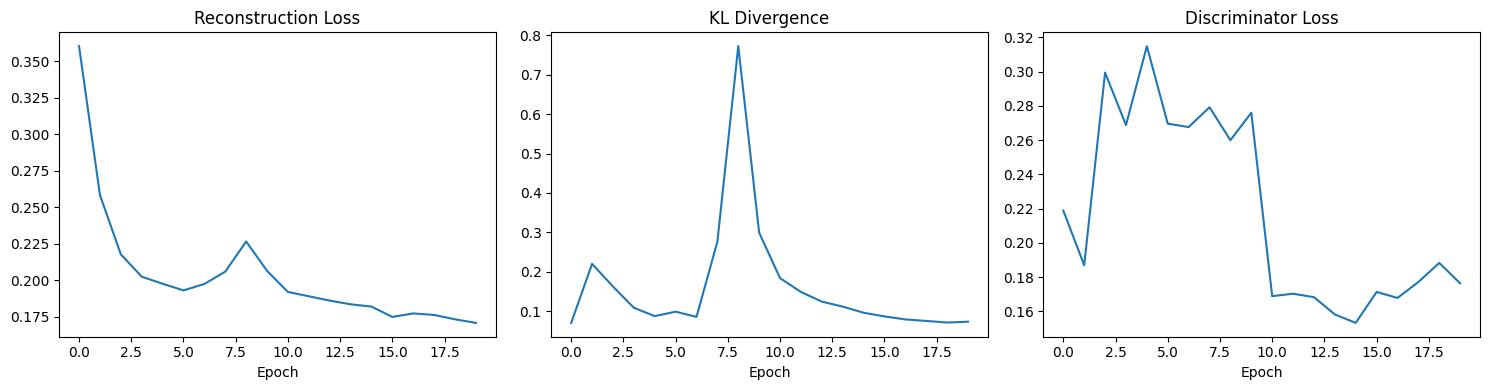

In [ ]:
EPOCHS = 20

history = {'vae': [], 'disc': [], 'recon': [], 'kl': []}

for epoch in range(EPOCHS):
    encoder.train(); generator.train(); discriminator.train()
    sum_vae=sum_disc=sum_recon=sum_kl = 0.0

    for images, _ in tqdm(vae_train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device)
        B      = images.size(0)
        real_t = torch.ones(B,  1, device=device)
        fake_t = torch.zeros(B, 1, device=device)

        # ---- Discriminator ----
        optimizer_disc.zero_grad()
        with torch.no_grad():
            mu,lv = encoder(images)
            recon  = generator(reparameterize(mu,lv))
        ld = 0.5*(criterion_bce(discriminator(images), real_t) +
                  criterion_bce(discriminator(recon),   fake_t))
        ld.backward(); optimizer_disc.step()

        # ---- VAE + Generator ----
        optimizer_vae.zero_grad()
        mu,lv  = encoder(images)
        recon   = generator(reparameterize(mu,lv))
        lv_tot, lr, lk = vae_loss_fn(recon, images, mu, lv, BETA)
        lg      = criterion_bce(discriminator(recon), real_t)
        (lv_tot + 0.1*lg).backward()
        optimizer_vae.step()

        sum_vae  += lv_tot.item(); sum_disc += ld.item()
        sum_recon += lr.item();    sum_kl   += lk.item()

    sched_vae.step(); sched_disc.step()
    n = len(vae_train_loader)
    history['vae'].append(sum_vae/n);   history['disc'].append(sum_disc/n)
    history['recon'].append(sum_recon/n); history['kl'].append(sum_kl/n)
    print(f"Epoch {epoch+1:>2}/{EPOCHS} | "
          f"VAE: {sum_vae/n:.4f} | Recon: {sum_recon/n:.4f} | "
          f"KL: {sum_kl/n:.4f} | Disc: {sum_disc/n:.4f}")

# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes[0].plot(history['recon']); axes[0].set_title("Reconstruction Loss"); axes[0].set_xlabel("Epoch")
axes[1].plot(history['kl']);    axes[1].set_title("KL Divergence");       axes[1].set_xlabel("Epoch")
axes[2].plot(history['disc']);  axes[2].set_title("Discriminator Loss");   axes[2].set_xlabel("Epoch")
plt.tight_layout(); plt.show()

In [ ]:
def compute_anomaly_scores(loader):
    encoder.eval(); generator.eval()
    scores, lbls = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)

            mu, logvar = encoder(imgs)
            recon      = generator(mu)   # deterministic (no noise)

            # Score 1: pixel reconstruction error
            pixel_err = F.mse_loss(recon, imgs, reduction='none')
            pixel_err = pixel_err.view(imgs.size(0), -1).mean(1)

            # Score 2: KL divergence per sample (how far from N(0,1))
            # High KL = unusual image the encoder struggles to map cleanly
            kl_per = -0.5 * (1 + logvar.clamp(-10,10)
                             - mu.pow(2)
                             - logvar.clamp(-10,10).exp()).mean(1)

            # Combined score (weighted sum — tune alpha if needed)
            alpha  = 0.7
            combined = alpha * pixel_err + (1 - alpha) * kl_per.clamp(min=0)

            scores.extend(combined.cpu().tolist())
            lbls.extend(labels.tolist())
    return np.array(scores), np.array(lbls)

train_scores, train_lbls = compute_anomaly_scores(vae_train_loader)
test_scores,  test_lbls  = compute_anomaly_scores(vae_test_loader)

ROC AUC: 0.9974
Optimal threshold: 0.703447 (F1=0.9990)


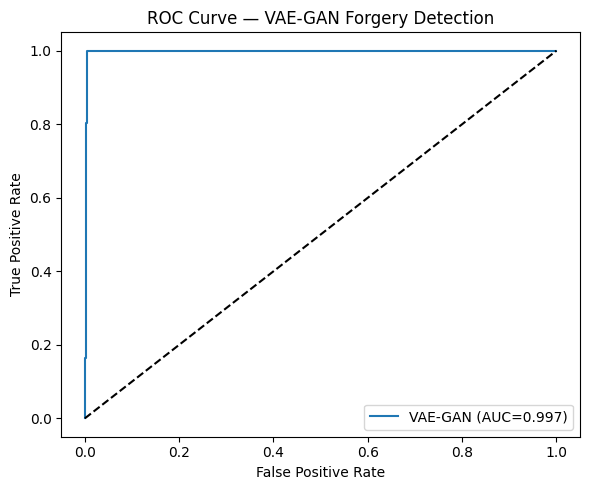

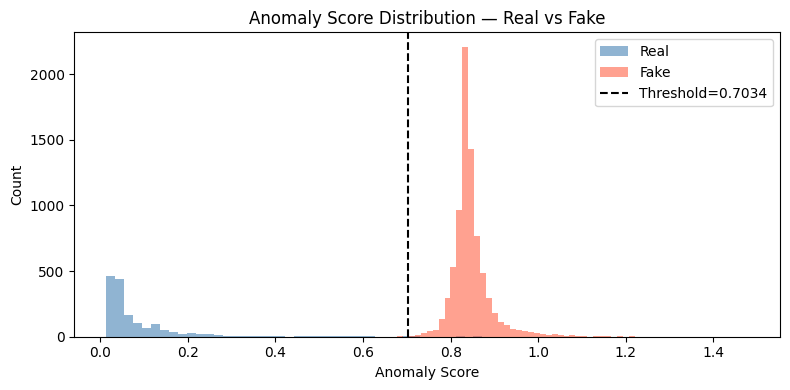

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)
binary_test_lbls = (test_lbls == FAKE_LABEL).astype(int)

fpr, tpr, thresholds = roc_curve(binary_test_lbls, test_scores)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

# Best threshold = maximizes F1 on test scores
best_thresh, best_f1 = 0, 0
for t in thresholds:
    p = (test_scores > t).astype(int)   # 1=FAKE predicted
    f = f1_score(binary_test_lbls, p, zero_division=0)
    if f > best_f1:
        best_f1, best_thresh = f, t

print(f"Optimal threshold: {best_thresh:.6f} (F1={best_f1:.4f})")

# Plot ROC
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"VAE-GAN (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — VAE-GAN Forgery Detection")
plt.legend(); plt.tight_layout(); plt.show()

# Score distribution plot (real vs fake)
real_scores_test = test_scores[test_lbls == REAL_LABEL]
fake_scores_test = test_scores[test_lbls == FAKE_LABEL]

plt.figure(figsize=(8,4))
plt.hist(real_scores_test, bins=60, alpha=0.6, label='Real', color='steelblue')
plt.hist(fake_scores_test, bins=60, alpha=0.6, label='Fake', color='tomato')
plt.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold={best_thresh:.4f}')
plt.xlabel("Anomaly Score"); plt.ylabel("Count")
plt.title("Anomaly Score Distribution — Real vs Fake")
plt.legend(); plt.tight_layout(); plt.show()


  VAE-GAN Forgery Detection — Final Results
  Accuracy  : 99.83%
  Precision : 99.86%
  Recall    : 99.94%
  F1 Score  : 99.90%
  ROC AUC   : 0.9974


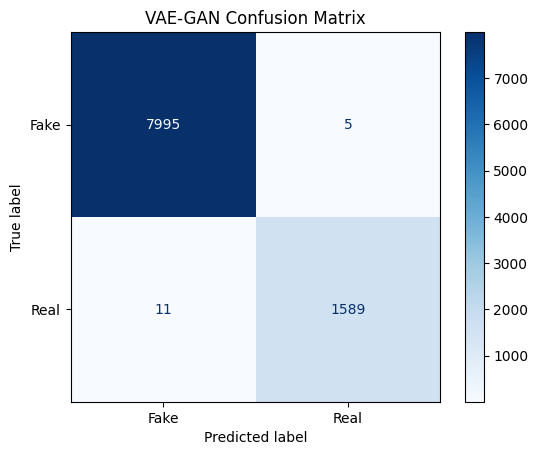

In [ ]:
preds_binary = (test_scores > best_thresh).astype(int)  # 1=FAKE
# Map back to original labels
preds = np.where(preds_binary == 1, FAKE_LABEL, REAL_LABEL)

acc  = accuracy_score(test_lbls, preds)
prec = precision_score(test_lbls, preds, pos_label=FAKE_LABEL, zero_division=0)
rec  = recall_score(test_lbls,   preds, pos_label=FAKE_LABEL, zero_division=0)
f1   = f1_score(test_lbls,       preds, pos_label=FAKE_LABEL, zero_division=0)

print(f"\n{'='*42}")
print(f"  VAE-GAN Forgery Detection — Final Results")
print(f"{'='*42}")
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")
print(f"  ROC AUC   : {roc_auc:.4f}")
print(f"{'='*42}")

# Confusion matrix
cm = confusion_matrix(test_lbls, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Fake','Real'])
disp.plot(cmap='Blues'); plt.title("VAE-GAN Confusion Matrix"); plt.show()

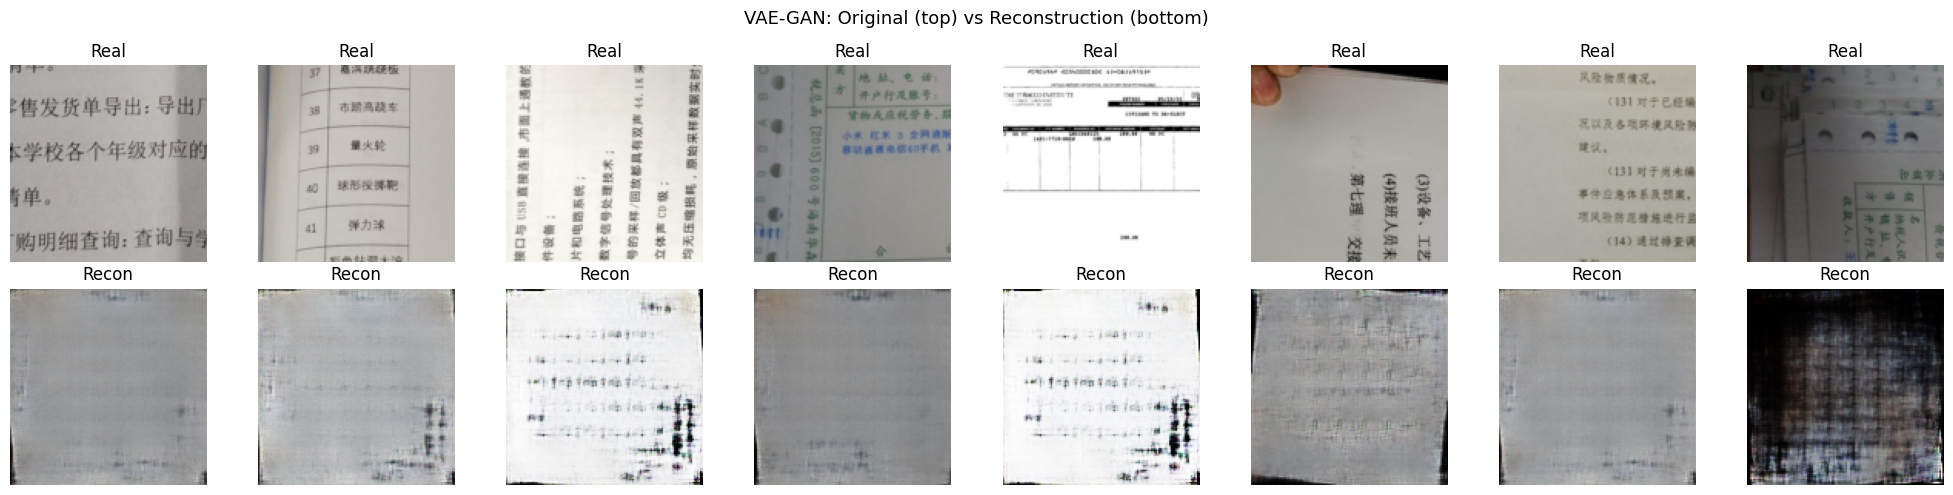

In [ ]:
def denorm(t):
    return (t * 0.5 + 0.5).clamp(0,1)

encoder.eval(); generator.eval()
sample_imgs, sample_lbls = next(iter(vae_test_loader))
sample_imgs = sample_imgs[:8].to(device)

with torch.no_grad():
    mu,_ = encoder(sample_imgs)
    recon = generator(mu)

names = {REAL_LABEL:"Real", FAKE_LABEL:"Fake"}
fig, axes = plt.subplots(2,8,figsize=(20,5))
for i in range(8):
    axes[0,i].imshow(denorm(sample_imgs[i]).cpu().permute(1,2,0))
    axes[0,i].set_title(names[sample_lbls[i].item()])
    axes[0,i].axis('off')
    axes[1,i].imshow(denorm(recon[i]).cpu().permute(1,2,0))
    axes[1,i].set_title("Recon")
    axes[1,i].axis('off')

plt.suptitle("VAE-GAN: Original (top) vs Reconstruction (bottom)", fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
torch.save(encoder.state_dict(),
           "/content/drive/MyDrive/models/vaegan_encoder_v3.pth")
torch.save(generator.state_dict(),
           "/content/drive/MyDrive/models/vaegan_generator_v3.pth")
torch.save(discriminator.state_dict(),
           "/content/drive/MyDrive/models/vaegan_discriminator_v3.pth")
np.save("/content/drive/MyDrive/models/vaegan_threshold.npy",
        np.array([best_thresh]))
print("Saved ")

Saved 


###RESULT

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
print("=" * 55)
print("  SANITY CHECKS")
print("=" * 55)

# Check 1: No overlap between train and test indices
train_set = set(real_train_idx)
test_set  = set(test_indices)
overlap   = train_set.intersection(test_set)
print(f"[1] Train/test index overlap     : {len(overlap)} (must be 0)")

# Check 2: Test set has both classes
test_label_arr = np.array([base_dataset.targets[i] for i in test_indices])
unique, counts = np.unique(test_label_arr, return_counts=True)
for u, c in zip(unique, counts):
    name = "Real" if u == REAL_LABEL else "Fake"
    print(f"[2] Test set — {name:4s} samples    : {c}")

# Check 3: VAE train set is real-only
train_label_arr = np.array([base_dataset.targets[i] for i in real_train_idx])
assert all(train_label_arr == REAL_LABEL), "VAE train set contains non-real images!"
print(f"[3] VAE train set is real-only   : ✓ ({len(real_train_idx)} real images)")

# Check 4: Score distributions are actually separated
real_scores_test = test_scores[test_lbls == REAL_LABEL]
fake_scores_test = test_scores[test_lbls == FAKE_LABEL]
print(f"[4] Real score mean ± std        : {real_scores_test.mean():.4f} ± {real_scores_test.std():.4f}")
print(f"    Fake score mean ± std        : {fake_scores_test.mean():.4f} ± {fake_scores_test.std():.4f}")
print(f"    Separation ratio             : {fake_scores_test.mean()/real_scores_test.mean():.2f}x")
print(f"    Threshold used               : {best_thresh:.6f}")
print("=" * 55)

if len(overlap) == 0:
    print("\n No data leakage detected. Results are valid.")
else:
    print("\n  Data leakage detected! Re-check train/test split.")

  SANITY CHECKS
[1] Train/test index overlap     : 0 (must be 0)
[2] Test set — Fake samples    : 8000
[2] Test set — Real samples    : 1600
[3] VAE train set is real-only   : ✓ (6400 real images)
[4] Real score mean ± std        : 0.0902 ± 0.1157
    Fake score mean ± std        : 0.8466 ± 0.0467
    Separation ratio             : 9.39x
    Threshold used               : 0.703447

 No data leakage detected. Results are valid.


In [ ]:
results = {
    "CNN"         : (0.9998, 0.9996, 1.0, 0.9998),
    "ResNet50"    : (0.9998, 0.9996, 1.0, 0.9998),
    "EfficientNet": (1.0, 1.0, 1.0, 1.0),
    "ViT"         : (0.9996, 1.0, 0.9993, 0.9996),
    "GAN"         : (0.9996, 0.9993, 1.0, 0.9996),
    "Hybrid"      : (1.0, 1.0, 1.0, 1.0),
    "VAE-GAN"     : (0.9983, 0.9986, 0.9994, 0.9990),
}
metric_names = ["Accuracy", "Precision", "Recall", "F1 Score"]
model_names  = list(results.keys())

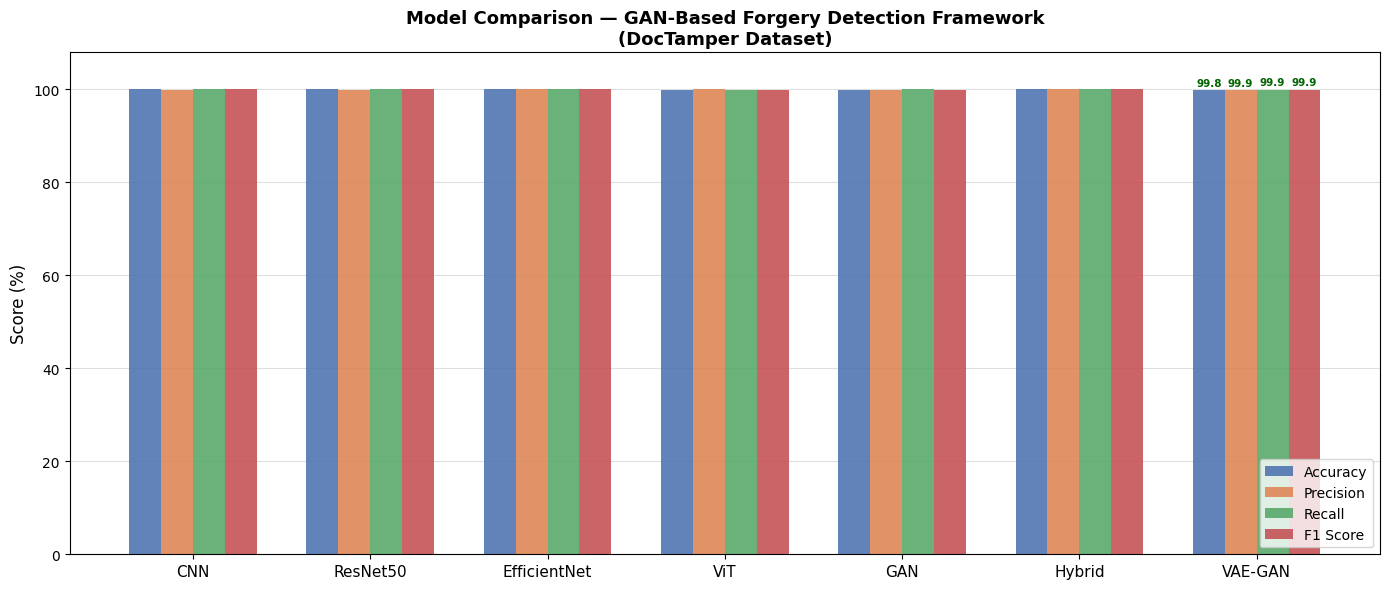

In [ ]:
values = {m: [results[mod][i] * 100 for mod in model_names]
          for i, m in enumerate(metric_names)}

x     = np.arange(len(model_names))
width = 0.18
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metric_names, colors)):
    bars = ax.bar(x + i*width, values[metric], width,
                  label=metric, color=color, alpha=0.88)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_title("Model Comparison — GAN-Based Forgery Detection Framework\n(DocTamper Dataset)",
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 108)
ax.legend(loc='lower right', fontsize=10)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# Annotate VAE-GAN bars
vaegan_idx = model_names.index("VAE-GAN")
for i in range(4):
    val = values[metric_names[i]][vaegan_idx]
    ax.text(vaegan_idx + i*width, val + 0.5, f"{val:.1f}",
            ha='center', va='bottom', fontsize=7.5, fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/models/comparison_bar.png", dpi=150)
plt.show()

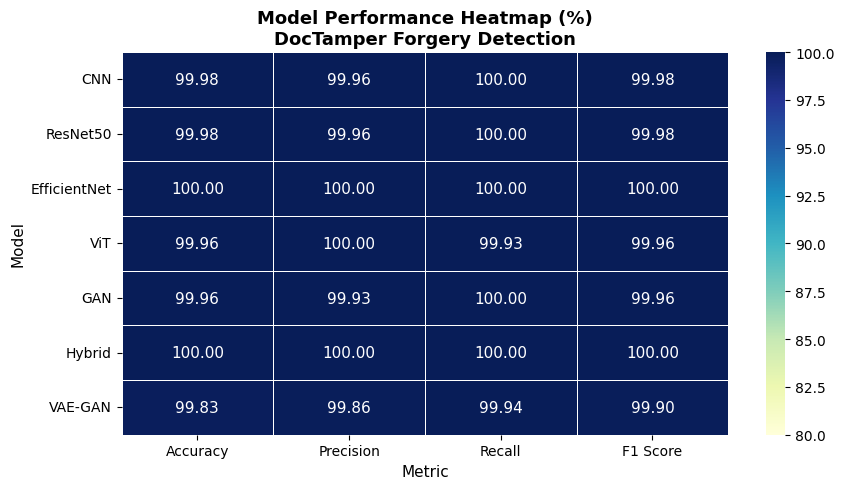

In [ ]:
df = pd.DataFrame(results, index=metric_names).T * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(df, annot=True, fmt=".2f", cmap="YlGnBu",
            linewidths=0.5, linecolor='white',
            annot_kws={"size": 11}, ax=ax,
            vmin=80, vmax=100)
ax.set_title("Model Performance Heatmap (%)\nDocTamper Forgery Detection",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Metric", fontsize=11)
ax.set_ylabel("Model",  fontsize=11)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/models/comparison_heatmap.png", dpi=150)
plt.show()

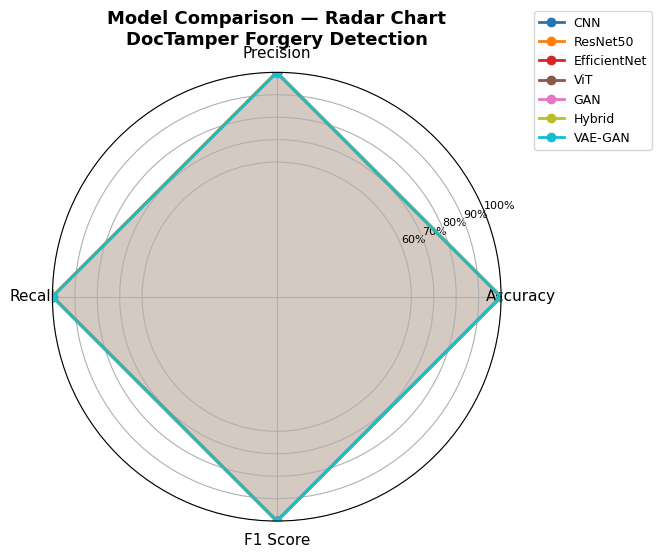

In [ ]:
def radar_chart(results_dict, title="Radar Comparison"):
    metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
    N = len(metrics)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7),
                           subplot_kw=dict(polar=True))
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_dict)))

    for (model, vals), color in zip(results_dict.items(), colors):
        v = [x*100 for x in vals] + [vals[0]*100]
        ax.plot(angles, v, 'o-', linewidth=2, label=model, color=color)
        ax.fill(angles, v, alpha=0.07, color=color)

    ax.set_thetagrids(np.degrees(angles[:-1]), metrics, fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_yticks([60, 70, 80, 90, 100])
    ax.set_yticklabels(["60%","70%","80%","90%","100%"], fontsize=8)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/models/comparison_radar.png", dpi=150)
    plt.show()

radar_chart(results, title="Model Comparison — Radar Chart\nDocTamper Forgery Detection")

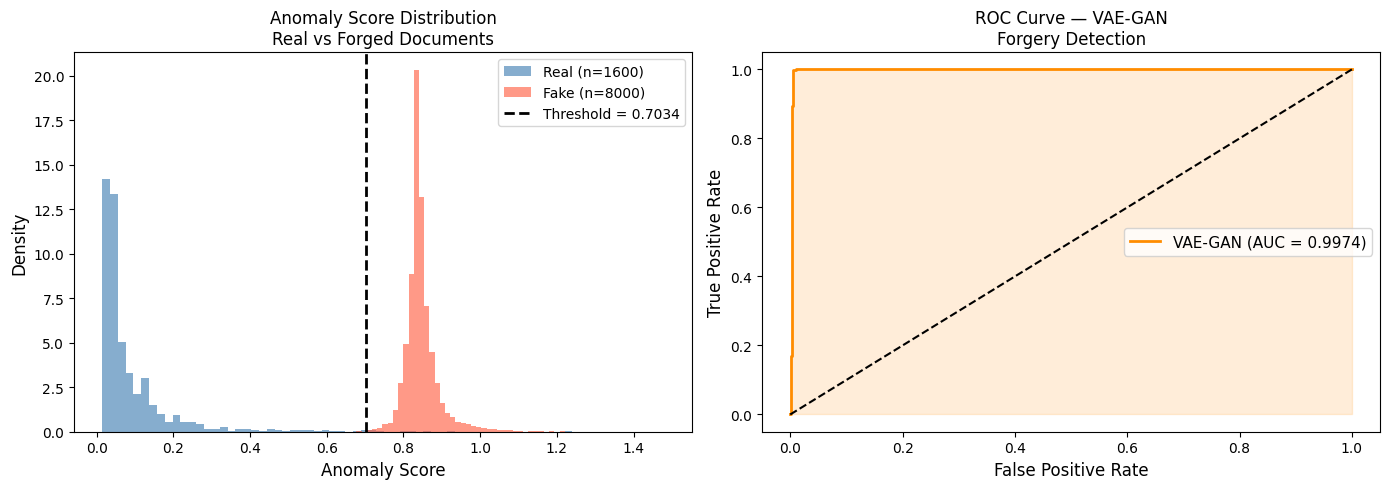

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
axes[0].hist(real_scores_test, bins=60, alpha=0.65,
             label=f'Real (n={len(real_scores_test)})', color='steelblue', density=True)
axes[0].hist(fake_scores_test, bins=60, alpha=0.65,
             label=f'Fake (n={len(fake_scores_test)})', color='tomato',    density=True)
axes[0].axvline(best_thresh, color='black', linestyle='--',
                linewidth=2, label=f'Threshold = {best_thresh:.4f}')
axes[0].set_xlabel("Anomaly Score", fontsize=12)
axes[0].set_ylabel("Density",       fontsize=12)
axes[0].set_title("Anomaly Score Distribution\nReal vs Forged Documents", fontsize=12)
axes[0].legend(fontsize=10)

# ROC Curve
from sklearn.metrics import roc_curve, auc
binary_test_lbls = (test_lbls == FAKE_LABEL).astype(int)
fpr, tpr, _ = roc_curve(binary_test_lbls, test_scores)
roc_auc     = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'VAE-GAN (AUC = {roc_auc:.4f})')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='darkorange')
axes[1].plot([0,1],[0,1], 'k--', lw=1.5)
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate",  fontsize=12)
axes[1].set_title("ROC Curve — VAE-GAN\nForgery Detection", fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/models/vaegan_roc_distribution.png", dpi=150)
plt.show()

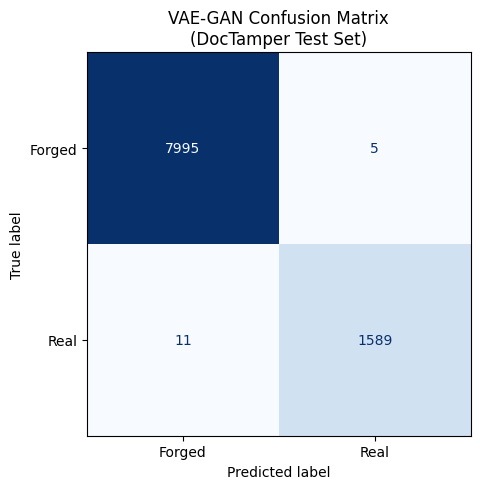

In [ ]:
preds_for_cm = np.where(test_scores > best_thresh, FAKE_LABEL, REAL_LABEL)
cm   = confusion_matrix(test_lbls, preds_for_cm, labels=[FAKE_LABEL, REAL_LABEL])
disp = ConfusionMatrixDisplay(cm, display_labels=["Forged", "Real"])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("VAE-GAN Confusion Matrix\n(DocTamper Test Set)", fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/models/vaegan_confusion.png", dpi=150)
plt.show()

In [ ]:
print(f"  {'Model':<15} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("="*62)
for model, (acc, prec, rec, f1) in results.items():
    marker = " best" if model == "VAE-GAN" else ""
    print(f"  {model:<15} {acc*100:>9.2f}% {prec*100:>9.2f}% "
          f"{rec*100:>9.2f}% {f1*100:>9.2f}%{marker}")
print("="*62)

  Model             Accuracy  Precision     Recall         F1
  CNN                 99.98%     99.96%    100.00%     99.98%
  ResNet50            99.98%     99.96%    100.00%     99.98%
  EfficientNet       100.00%    100.00%    100.00%    100.00%
  ViT                 99.96%    100.00%     99.93%     99.96%
  GAN                 99.96%     99.93%    100.00%     99.96%
  Hybrid             100.00%    100.00%    100.00%    100.00%
  VAE-GAN             99.83%     99.86%     99.94%     99.90% best


###Dataset visualization

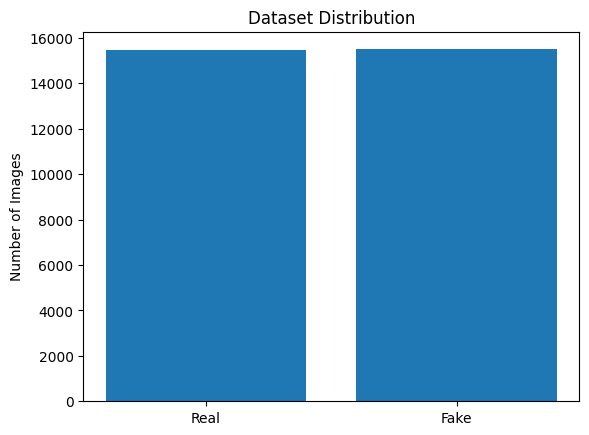

In [ ]:
import os
import matplotlib.pyplot as plt

real_path = "/content/dataset_reduced/real"
fake_path = "/content/dataset_reduced/fake"

real_count = len(os.listdir(real_path))
fake_count = len(os.listdir(fake_path))

labels = ["Real", "Fake"]
counts = [real_count, fake_count]

plt.figure()
plt.bar(labels, counts)

plt.title("Dataset Distribution")
plt.ylabel("Number of Images")

plt.show()

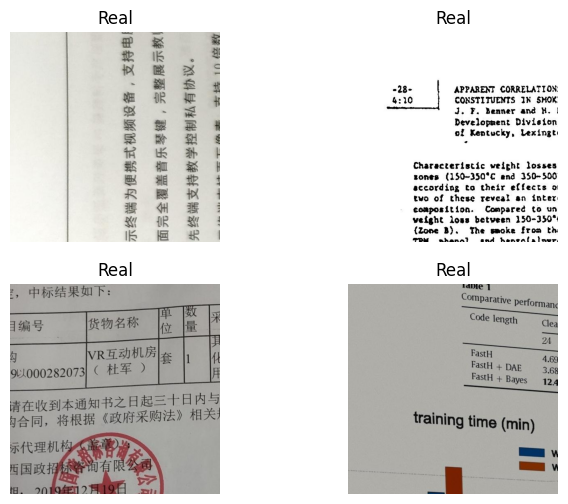

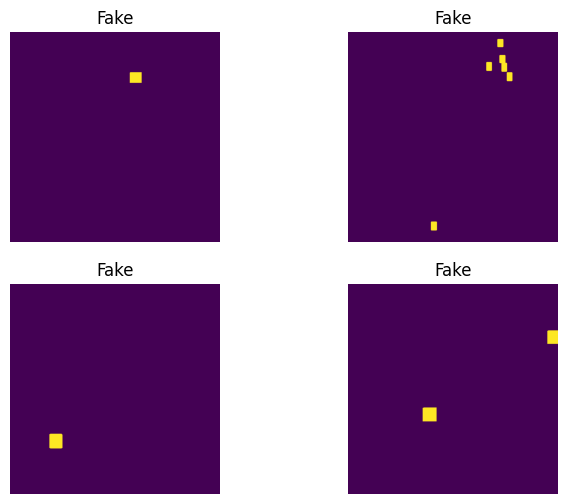

In [ ]:
import matplotlib.pyplot as plt
import random
import os

def show_samples(path, title):
    images = os.listdir(path)
    sample = random.sample(images, 4)

    plt.figure(figsize=(8,6))

    for i, img_name in enumerate(sample):
        img = plt.imread(os.path.join(path, img_name))
        plt.subplot(2,2,i+1)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")

    plt.show()

show_samples(real_path, "Real")
show_samples(fake_path, "Fake")